# Compare FTW configurations on real images

This notebook quantitatively compares `ftw_mask_baseline` with
`ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf` on the same held-out
**real FTW test images** from Austria, Croatia, and Denmark. Evaluation explicitly
disables all augmentation.

`ftw_dual_head_boundary_bce_w20_s012` is included only in section 6 for a three-config
visual comparison on identical images.

## tl;dr

Run all cells. The quantitative result reports whether
`ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf` improves Boundary IoU over
`ftw_mask_baseline`, overall and within each country, including a paired bootstrap 95%
confidence interval. Section 6 shows representative masks from all three configurations.

## Context & Methods

### Key assumptions

- `ftw_mask_baseline` is an 8-channel mask-only U-Net. `ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf` uses the same U-Net backbone width, adds an explicit boundary head, and disables the SDF head.
- Both quantitative checkpoints are saved models selected by validation Boundary IoU.
- Both models use threshold `0.5` and the project's Boundary IoU definition: a 2-pixel
  inner boundary obtained by morphological erosion.
- The official FTW `test` split is used, restricted to the three requested countries.
- Metrics are paired per image. This controls for image difficulty and avoids comparing
  different random image sets.
- `ftw_dual_head_boundary_bce_w20_s012` is visualized in section 6 but intentionally excluded from all quantitative tables, distributions, confidence intervals, and gain/regression lists.

The default run evaluates a balanced, deterministic sample from every country. Set
`EVAL_SAMPLES_PER_COUNTRY = None` to evaluate every available test image.

In [1]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display
from torch.utils.data import DataLoader, Subset


def find_project_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "Saved").is_dir():
            return candidate.resolve()
        nested = candidate / "HLCV_final_project"
        if (nested / "src").is_dir() and (nested / "Saved").is_dir():
            return nested.resolve()
    raise FileNotFoundError("Could not locate HLCV_final_project from the current directory.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loaders.field_dataset import FTWFieldDataset
from src.models.unet import DualHeadUNet, MaskOnlyUNet, ThreeHeadUNet

SEED = 12
COUNTRIES = ["austria", "croatia", "denmark"]
SPLIT = "test"
IMAGE_SIZE = 256
THRESHOLD = 0.5
BOUNDARY_RADIUS = 2
BATCH_SIZE = 4
EVAL_SAMPLES_PER_COUNTRY = 40  # None = full test split
VISUAL_SAMPLES_PER_COUNTRY = 3
BOOTSTRAP_REPEATS = 5_000

BASELINE_CONFIG = "ftw_mask_baseline"
DUAL_HEAD_CONFIG = "ftw_dual_head_boundary_bce_w20_s012"
THREE_HEAD_CONFIG = "ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf"

CHECKPOINTS = {
    BASELINE_CONFIG: PROJECT_ROOT / "Saved/ftw_mask_baseline/best_eval_boundary_iou_model.pth",
    DUAL_HEAD_CONFIG: PROJECT_ROOT / "Saved/ftw_dual_head_boundary_bce_w20_s012/best_eval_boundary_iou_model.pth",
    THREE_HEAD_CONFIG: PROJECT_ROOT / "Saved/ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf/best_eval_boundary_iou_model.pth",
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Project: {PROJECT_ROOT}")
print(f"Device:  {DEVICE}")

Project: /Users/daddysugar/Documents/Lectures/HLCV/HLCV_final_project
Device:  mps


### 1. Load the three configuration checkpoints

`ftw_mask_baseline` and `ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf`
are used in every quantitative section. `ftw_dual_head_boundary_bce_w20_s012` is loaded
only for section 6. The loader accepts a raw state dictionary or a training checkpoint
containing `model_state`.

In [2]:
def load_state_dict(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {path}")
    try:
        state = torch.load(path, map_location=DEVICE, weights_only=True)
    except TypeError:  # older PyTorch
        state = torch.load(path, map_location=DEVICE)
    if isinstance(state, dict) and "model_state" in state:
        state = state["model_state"]
    if any(key.startswith("module.") for key in state):
        state = {key.removeprefix("module."): value for key, value in state.items()}
    return state


def build_model(model_class, checkpoint_path, **model_kwargs):
    model = model_class(
        in_channels=8,
        base_channels=32,
        num_classes=1,
        bilinear=False,
        **model_kwargs,
    ).to(DEVICE)
    model.load_state_dict(load_state_dict(checkpoint_path), strict=True)
    model.eval()
    return model


baseline_model = build_model(MaskOnlyUNet, CHECKPOINTS[BASELINE_CONFIG])
dual_head_model = build_model(DualHeadUNet, CHECKPOINTS[DUAL_HEAD_CONFIG])
three_head_model = build_model(
    ThreeHeadUNet, CHECKPOINTS[THREE_HEAD_CONFIG], predict_distance=False
)

# Only these two configurations enter metrics, summaries, charts, and diagnostic tables.
evaluation_models = {
    BASELINE_CONFIG: baseline_model,
    THREE_HEAD_CONFIG: three_head_model,
}

# Section 6 uses all three configurations, in this display order.
visual_models = {
    BASELINE_CONFIG: baseline_model,
    DUAL_HEAD_CONFIG: dual_head_model,
    THREE_HEAD_CONFIG: three_head_model,
}

for config_name, checkpoint_path in CHECKPOINTS.items():
    print(f"Loaded {config_name}: {checkpoint_path.relative_to(PROJECT_ROOT)}")

Loaded ftw_mask_baseline: Saved/ftw_mask_baseline/best_eval_boundary_iou_model.pth
Loaded ftw_dual_head_boundary_bce_w20_s012: Saved/ftw_dual_head_boundary_bce_w20_s012/best_eval_boundary_iou_model.pth
Loaded ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf: Saved/ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf/best_eval_boundary_iou_model.pth


## Data

### 2. Build a non-augmented real-image test set

`transform=None` and `augment=False` are set directly rather than inherited from a
training configuration. The image tensor is the original pair of Sentinel-2 windows,
rescaled and resized by the project dataset loader only.

In [3]:
dataset = FTWFieldDataset(
    data_dir=PROJECT_ROOT / "data/ftw",
    split=SPLIT,
    countries=COUNTRIES,
    image_size=IMAGE_SIZE,
    sdf_cache_dir=PROJECT_ROOT / "sdf_cache",
    transform=None,
    augment=False,
)

assert dataset.transform is None
assert dataset.augment is False
assert set(country for country, _ in dataset.samples) == set(COUNTRIES)

availability = pd.Series(
    [country for country, _ in dataset.samples], name="country"
).value_counts().reindex(COUNTRIES).rename("available_test_images").to_frame()
display(availability)
print(f"Total available real test images: {len(dataset):,}")

,available_test_images
austria,745
croatia,353
denmark,332


Total available real test images: 1,430


### 3. Choose the same deterministic samples for both models

Sampling is balanced by country. Visual samples are a fixed subset of the evaluated
images; they are not selected according to which model wins.

In [4]:
def balanced_indices(samples, countries, per_country, seed):
    rng = np.random.default_rng(seed)
    selected = []
    by_country = {country: [] for country in countries}
    for index, (country, _) in enumerate(samples):
        if country in by_country:
            by_country[country].append(index)
    for country in countries:
        candidates = np.asarray(by_country[country])
        take = len(candidates) if per_country is None else min(per_country, len(candidates))
        selected.extend(rng.choice(candidates, size=take, replace=False).tolist())
    return selected


eval_indices = balanced_indices(
    dataset.samples, COUNTRIES, EVAL_SAMPLES_PER_COUNTRY, SEED
)
evaluation_loader = DataLoader(
    Subset(dataset, eval_indices),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

sample_counts = pd.Series(
    [dataset.samples[index][0] for index in eval_indices], name="country"
).value_counts().reindex(COUNTRIES).rename("evaluated_images").to_frame()
display(sample_counts)

,evaluated_images
austria,40
croatia,40
denmark,40


## Results

### 4. Compute paired Mask IoU and Boundary IoU

Each row below corresponds to one real image evaluated by `ftw_mask_baseline` and
`ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf`. Boundary IoU uses exactly
the same radius and threshold for both configurations.

In [5]:
def mask_boundary(mask, radius=2):
    kernel_size = 2 * radius + 1
    eroded = -F.max_pool2d(
        -mask.float(), kernel_size=kernel_size, stride=1, padding=radius
    )
    return (mask.float() - eroded).clamp(min=0.0)


def per_image_metrics(prediction, target, radius=2):
    prediction = prediction.bool()
    target = target.bool()
    intersection = (prediction & target).flatten(1).sum(1).float()
    union = (prediction | target).flatten(1).sum(1).float()
    pred_boundary = mask_boundary(prediction.float(), radius)
    target_boundary = mask_boundary(target.float(), radius)
    boundary_intersection = (pred_boundary * target_boundary).flatten(1).sum(1)
    boundary_union = ((pred_boundary + target_boundary) > 0).flatten(1).sum(1).float()
    eps = 1e-6
    return (
        ((intersection + eps) / (union + eps)).cpu().numpy(),
        ((boundary_intersection + eps) / (boundary_union + eps)).cpu().numpy(),
    )


rows = []
with torch.inference_mode():
    for batch in evaluation_loader:
        images = batch["image"].to(DEVICE)
        targets = batch["mask"].to(DEVICE) > 0.5
        batch_results = {}
        for model_name, model in evaluation_models.items():
            probabilities = torch.sigmoid(model(images)["mask_logits"])
            predictions = probabilities > THRESHOLD
            batch_results[model_name] = per_image_metrics(
                predictions, targets, BOUNDARY_RADIUS
            )
        target_fractions = targets.float().flatten(1).mean(1).cpu().numpy()
        for item_index, sample_id in enumerate(batch["id"]):
            country, aoi_id = sample_id.split("/", 1)
            rows.append({
                "id": sample_id,
                "country": country,
                "aoi_id": aoi_id,
                "target_fraction": target_fractions[item_index],
                "baseline_mask_iou": batch_results[BASELINE_CONFIG][0][item_index],
                "new_mask_iou": batch_results[THREE_HEAD_CONFIG][0][item_index],
                "baseline_boundary_iou": batch_results[BASELINE_CONFIG][1][item_index],
                "new_boundary_iou": batch_results[THREE_HEAD_CONFIG][1][item_index],
            })

results = pd.DataFrame(rows)
results["mask_iou_delta"] = results["new_mask_iou"] - results["baseline_mask_iou"]
results["boundary_iou_delta"] = (
    results["new_boundary_iou"] - results["baseline_boundary_iou"]
)
assert results["id"].is_unique
assert np.isfinite(results.select_dtypes("number")).all().all()
display(results.head().round(4))

,id,country,aoi_id,target_fraction,baseline_mask_iou,new_mask_iou,baseline_boundary_iou,new_boundary_iou,mask_iou_delta,boundary_iou_delta
0,austria/g78_00028_17,austria,g78_00028_17,0.2292,0.7515,0.7616,0.4189,0.4620,0.0102,0.0432
1,austria/g83_00021_4,austria,g83_00021_4,0.4645,0.7739,0.7698,0.3907,0.4594,-0.0041,0.0687
2,austria/g78_00008_12,austria,g78_00008_12,0.0520,0.5723,0.6216,0.4499,0.4811,0.0493,0.0312
3,austria/g95_00030_1,austria,g95_00030_1,0.3688,0.6721,0.6879,0.2840,0.3776,0.0158,0.0936
4,austria/g82_00037_13,austria,g82_00037_13,0.6977,0.7790,0.7796,0.2545,0.3493,0.0006,0.0948


### 5. Summarize the paired improvement with uncertainty

The confidence interval bootstraps per-image deltas between
`ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf` and `ftw_mask_baseline`.
A positive interval excludes zero for this sample; it does not imply that every image
improves.

In [6]:
def bootstrap_mean_ci(values, repeats=5_000, seed=0):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    draws = rng.choice(values, size=(repeats, len(values)), replace=True).mean(axis=1)
    return np.quantile(draws, [0.025, 0.975])


summary_rows = []
groups = [(country, results[results.country == country]) for country in COUNTRIES]
groups.append(("overall", results))
for group_number, (country, frame) in enumerate(groups):
    low, high = bootstrap_mean_ci(
        frame["boundary_iou_delta"], BOOTSTRAP_REPEATS, SEED + group_number
    )
    summary_rows.append({
        "country": country,
        "n": len(frame),
        "baseline_mask_iou": frame["baseline_mask_iou"].mean(),
        "new_mask_iou": frame["new_mask_iou"].mean(),
        "mask_iou_delta": frame["mask_iou_delta"].mean(),
        "baseline_boundary_iou": frame["baseline_boundary_iou"].mean(),
        "new_boundary_iou": frame["new_boundary_iou"].mean(),
        "boundary_iou_delta": frame["boundary_iou_delta"].mean(),
        "delta_ci_95_low": low,
        "delta_ci_95_high": high,
        "new_win_rate": (frame["boundary_iou_delta"] > 0).mean(),
    })

summary = pd.DataFrame(summary_rows).set_index("country")
display(summary.round(4))

overall = summary.loc["overall"]
if overall["delta_ci_95_low"] > 0:
    verdict = "supports"
elif overall["delta_ci_95_high"] < 0:
    verdict = "contradicts"
else:
    verdict = "does not establish"
print(
    f"This paired sample {verdict} a Boundary IoU improvement for {THREE_HEAD_CONFIG} over {BASELINE_CONFIG}: "
    f"mean delta={overall['boundary_iou_delta']:+.4f}, "
    f"95% CI [{overall['delta_ci_95_low']:+.4f}, "
    f"{overall['delta_ci_95_high']:+.4f}]."
)

,n,baseline_mask_iou,new_mask_iou,mask_iou_delta,baseline_boundary_iou,new_boundary_iou,boundary_iou_delta,delta_ci_95_low,delta_ci_95_high,new_win_rate
country,,,,,,,,,,
austria,40,0.6591,0.6990,0.0398,0.3448,0.4010,0.0562,0.0436,0.0688,0.9000
croatia,40,0.6381,0.6569,0.0188,0.3073,0.3730,0.0658,0.0335,0.1212,0.7250
denmark,40,0.7967,0.7900,-0.0068,0.3391,0.3889,0.0498,0.0382,0.0616,0.9000
overall,120,0.6980,0.7153,0.0173,0.3304,0.3877,0.0573,0.0440,0.0765,0.8417


This paired sample supports a Boundary IoU improvement for ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf over ftw_mask_baseline: mean delta=+0.0573, 95% CI [+0.0440, +0.0765].


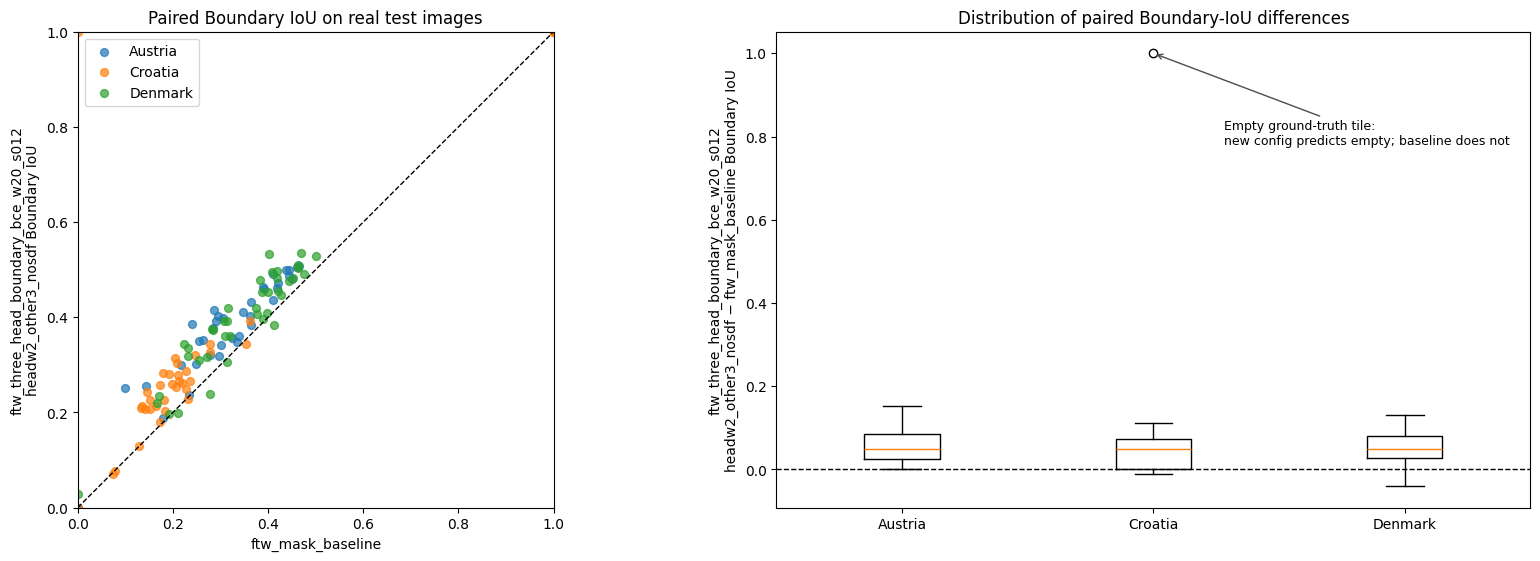

Boxplot note: circles beyond the whiskers are per-image outliers (more than 1.5×IQR from the box). The +1.0 point is croatia/g14-2_00047_12: its ground truth is empty; ftw_mask_baseline predicts foreground (IoU 0), while ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf predicts empty (IoU 1).


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), constrained_layout=True)

for country, frame in results.groupby("country", sort=False):
    axes[0].scatter(
        frame["baseline_boundary_iou"], frame["new_boundary_iou"],
        s=32, alpha=0.7, label=country.title()
    )
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set(
    xlim=(0, 1), ylim=(0, 1), aspect="equal",
    xlabel=BASELINE_CONFIG,
    ylabel="ftw_three_head_boundary_bce_w20_s012\nheadw2_other3_nosdf Boundary IoU",
    title="Paired Boundary IoU on real test images",
)
axes[0].legend()

delta_data = [
    results.loc[results.country == country, "boundary_iou_delta"]
    for country in COUNTRIES
]
axes[1].boxplot(
    delta_data,
    tick_labels=[c.title() for c in COUNTRIES],
    showfliers=True,
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set(
    ylabel=(
        "ftw_three_head_boundary_bce_w20_s012\n"
        "headw2_other3_nosdf − ftw_mask_baseline Boundary IoU"
    ),
    title="Distribution of paired Boundary-IoU differences",
)

perfect_gain = results[np.isclose(results["boundary_iou_delta"], 1.0)]
if not perfect_gain.empty:
    outlier = perfect_gain.iloc[0]
    country_position = COUNTRIES.index(outlier["country"]) + 1
    axes[1].annotate(
        "Empty ground-truth tile:\nnew config predicts empty; baseline does not",
        xy=(country_position, outlier["boundary_iou_delta"]),
        xytext=(country_position + 0.28, 0.78),
        arrowprops=dict(arrowstyle="->", color="0.3"),
        fontsize=9,
        ha="left",
    )

plt.show()

print(
    "Boxplot note: circles beyond the whiskers are per-image outliers (more than 1.5×IQR "
    "from the box). The +1.0 point is croatia/g14-2_00047_12: its ground truth is empty; "
    "ftw_mask_baseline predicts foreground (IoU 0), while "
    "ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf predicts empty (IoU 1)."
)

### 6. Inspect representative real images side by side

Examples are selected deterministically after inference. For each country, the notebook
chooses three non-empty scenes with different foreground coverage whose Boundary-IoU
change is close to that country's median. This avoids empty tiles and extreme wins or
losses while retaining varied field layouts.

The columns show the real image, ground truth, and predictions from
`ftw_mask_baseline`, `ftw_dual_head_boundary_bce_w20_s012`, and
`ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf`.

,country,target_fraction,rgb_high_saturation,boundary_iou_delta
id,,,,
austria/g78_00030_5,austria,0.1049,0.0000,0.0618
austria/g94_00047_3,austria,0.3721,0.0000,0.0681
austria/g83_00021_4,austria,0.4645,0.0041,0.0687
croatia/g10-3_00043_10,croatia,0.3474,0.0007,0.0600
croatia/g14-2_00068_3,croatia,0.3946,0.0000,0.0541
croatia/g14-2_00011_9,croatia,0.5401,0.0011,0.0585
denmark/g6_00035_3,denmark,0.4096,0.0000,0.0411
denmark/g6_00099_17,denmark,0.6075,0.0001,0.0308
denmark/g6_00067_9,denmark,0.7703,0.0000,0.0348


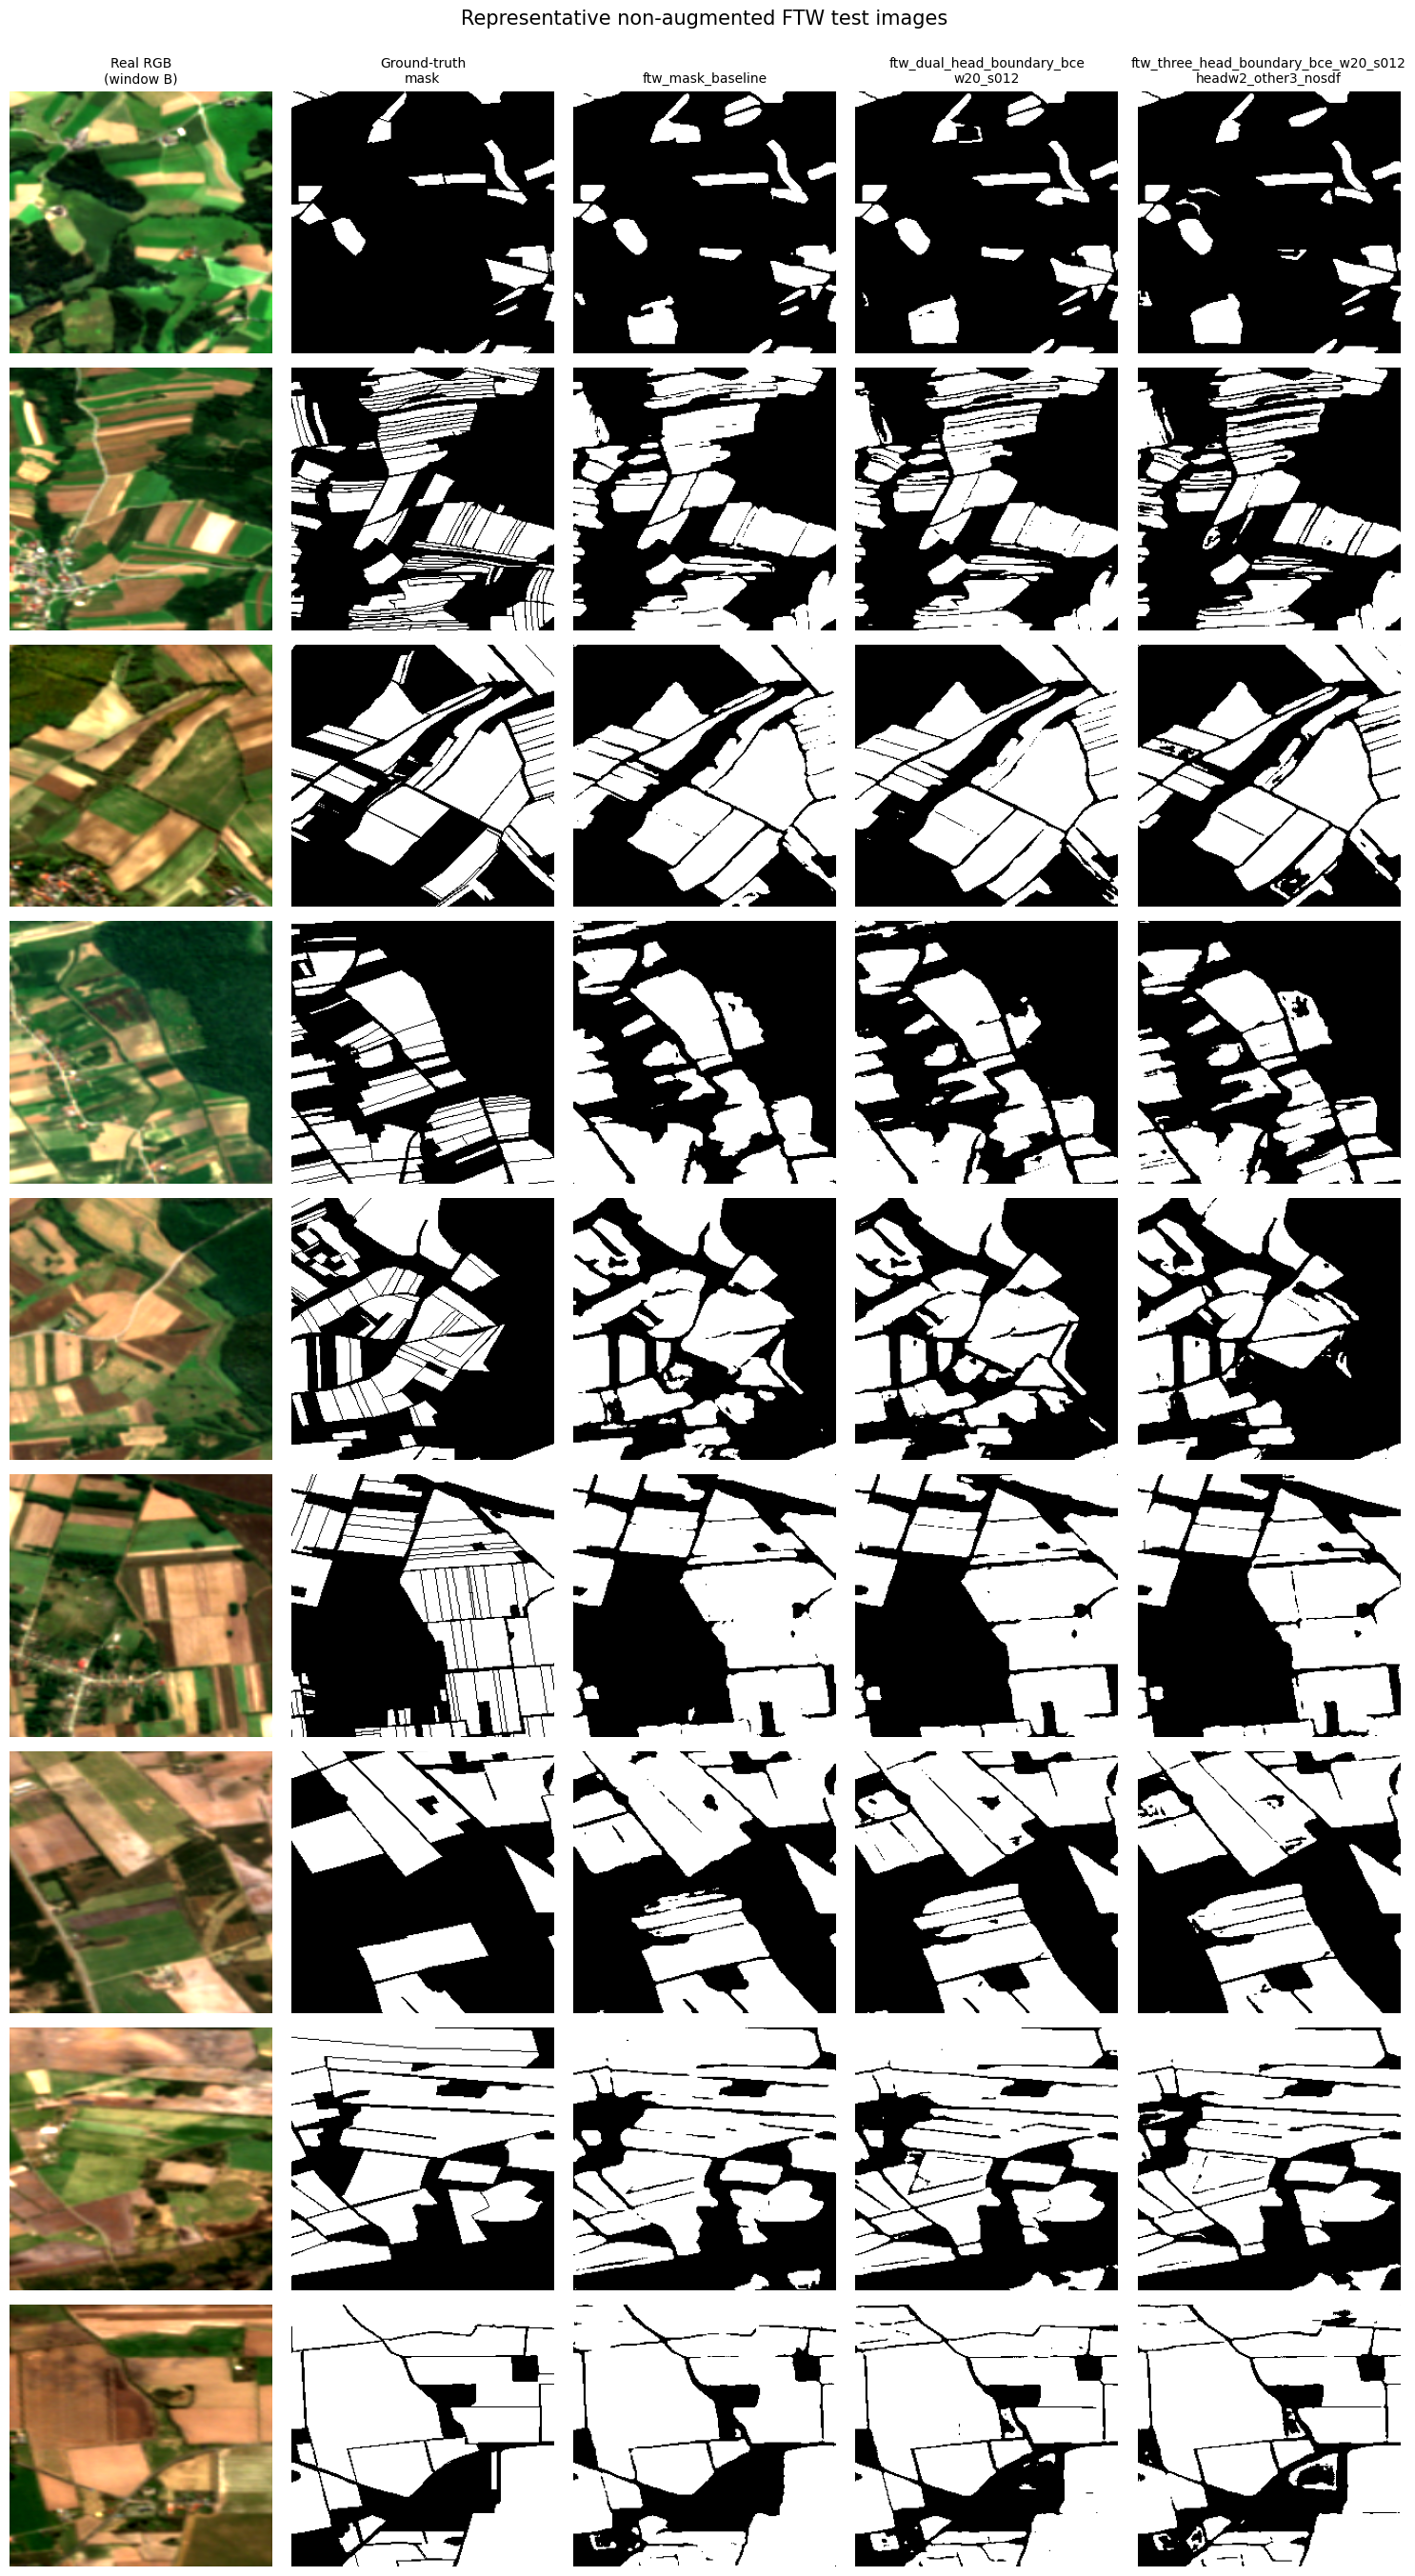

In [8]:
def rgb_for_display(image):
    rgb = image[:3].permute(1, 2, 0).cpu().numpy()
    low, high = np.percentile(rgb, [2, 98])
    return np.clip((rgb - low) / max(high - low, 1e-6), 0, 1)


def select_representative_ids(results_frame, countries, per_country=3):
    selected_ids = []
    for country in countries:
        country_rows = results_frame[results_frame["country"] == country].copy()
        eligible = country_rows[
            country_rows["target_fraction"].between(0.08, 0.92)
            & (country_rows["rgb_high_saturation"] < 0.20)
        ].copy()
        if len(eligible) < per_country:
            eligible = country_rows[country_rows["target_fraction"] > 0].copy()

        median_delta = eligible["boundary_iou_delta"].median()
        coverage_targets = eligible["target_fraction"].quantile(
            np.linspace(0.25, 0.75, per_country)
        ).to_numpy()
        delta_scale = max(eligible["boundary_iou_delta"].std(), 1e-6)
        coverage_scale = max(eligible["target_fraction"].std(), 1e-6)
        used = set()
        for coverage_target in coverage_targets:
            candidates = eligible[~eligible["id"].isin(used)].copy()
            candidates["representative_score"] = (
                (candidates["boundary_iou_delta"] - median_delta).abs() / delta_scale
                + 0.45
                * (candidates["target_fraction"] - coverage_target).abs()
                / coverage_scale
            )
            chosen = candidates.sort_values(
                ["representative_score", "id"]
            ).iloc[0]
            selected_ids.append(chosen["id"])
            used.add(chosen["id"])
    return selected_ids


id_to_dataset_index = {
    f"{country}/{aoi_id}": index
    for index, (country, aoi_id) in enumerate(dataset.samples)
}


def rgb_high_saturation_fraction(sample_id):
    rgb = dataset[id_to_dataset_index[sample_id]]["image"][:3]
    return (rgb > 0.98).float().mean().item()


selection_frame = results.copy()
selection_frame["rgb_high_saturation"] = [
    rgb_high_saturation_fraction(sample_id) for sample_id in selection_frame["id"]
]
representative_ids = select_representative_ids(
    selection_frame, COUNTRIES, VISUAL_SAMPLES_PER_COUNTRY
)
visual_dataset_indices = [id_to_dataset_index[sample_id] for sample_id in representative_ids]

representative_summary = selection_frame.set_index("id").loc[
    representative_ids,
    ["country", "target_fraction", "rgb_high_saturation", "boundary_iou_delta"],
]
display(representative_summary.round(4))


def predict_one_with_all_configs(sample):
    image = sample["image"].unsqueeze(0).to(DEVICE)
    predictions = {}
    with torch.inference_mode():
        for config_name, model in visual_models.items():
            predictions[config_name] = (
                torch.sigmoid(model(image)["mask_logits"])[0, 0] > THRESHOLD
            ).float().cpu()
    return predictions


fig, axes = plt.subplots(
    len(visual_dataset_indices), 5,
    figsize=(15, 3.0 * len(visual_dataset_indices)),
    squeeze=False,
)
for row_index, dataset_index in enumerate(visual_dataset_indices):
    sample = dataset[dataset_index]
    rgb = rgb_for_display(sample["image"])
    target = sample["mask"][0].float()
    predictions = predict_one_with_all_configs(sample)

    panels = [
        (rgb, "Real RGB\n(window B)"),
        (target.numpy(), "Ground-truth\nmask"),
        (predictions[BASELINE_CONFIG].numpy(), "ftw_mask_baseline"),
        (
            predictions[DUAL_HEAD_CONFIG].numpy(),
            "ftw_dual_head_boundary_bce\nw20_s012",
        ),
        (
            predictions[THREE_HEAD_CONFIG].numpy(),
            "ftw_three_head_boundary_bce_w20_s012\nheadw2_other3_nosdf",
        ),
    ]
    for column_index, (panel, title) in enumerate(panels):
        axes[row_index, column_index].imshow(
            panel, cmap="gray" if panel.ndim == 2 else None
        )
        axes[row_index, column_index].axis("off")
        if row_index == 0:
            axes[row_index, column_index].set_title(title, fontsize=10)
    axes[row_index, 0].set_ylabel(
        sample["id"], rotation=0, ha="right", va="center", fontsize=8
    )

fig.suptitle(
    "Representative non-augmented FTW test images",
    y=1.0,
    fontsize=15,
)
fig.tight_layout()
plt.show()

### 7. Inspect strongest gains and regressions

This table compares only `ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf`
with `ftw_mask_baseline`. It deliberately shows both tails of the paired delta. The empty
Croatia tile may appear as a `+1.0` gain under the project's empty-mask IoU convention.

In [9]:
columns = [
    "id", "baseline_boundary_iou", "new_boundary_iou", "boundary_iou_delta",
    "baseline_mask_iou", "new_mask_iou", "mask_iou_delta",
]
largest_gains = results.nlargest(5, "boundary_iou_delta")[columns]
largest_regressions = results.nsmallest(5, "boundary_iou_delta")[columns]
print("Largest Boundary IoU gains")
display(largest_gains.round(4))
print("Largest Boundary IoU regressions")
display(largest_regressions.round(4))

Largest Boundary IoU gains


,id,baseline_boundary_iou,new_boundary_iou,boundary_iou_delta,baseline_mask_iou,new_mask_iou,mask_iou_delta
46,croatia/g14-2_00047_12,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000
22,austria/g79_00026_16,0.0993,0.2510,0.1518,0.1009,0.3410,0.2401
13,austria/g82_00014_1,0.2405,0.3848,0.1443,0.8032,0.8282,0.0250
87,denmark/g6_00096_12,0.4018,0.5330,0.1312,0.9477,0.9572,0.0095
26,austria/g95_00013_9,0.2872,0.4159,0.1287,0.4123,0.7916,0.3792


Largest Boundary IoU regressions


,id,baseline_boundary_iou,new_boundary_iou,boundary_iou_delta,baseline_mask_iou,new_mask_iou,mask_iou_delta
107,denmark/g6_00023_17,0.2786,0.2387,-0.0399,0.6844,0.6093,-0.0751
95,denmark/g6_00030_13,0.4119,0.3828,-0.0290,0.6107,0.6004,-0.0103
108,denmark/g6_00062_12,0.2113,0.1989,-0.0124,0.6128,0.5839,-0.0289
45,croatia/g14-2_00059_18,0.3545,0.3435,-0.0110,0.7761,0.7661,-0.0101
90,denmark/g6_00092_6,0.3143,0.3067,-0.0076,0.5984,0.5641,-0.0343


## Takeaways

- Use the paired summary and confidence interval—not a few favorable images—to decide
  whether `ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf` improves Boundary IoU over `ftw_mask_baseline`.
- Check each country separately; an aggregate gain can hide a country-level regression.
- Compare Mask IoU alongside Boundary IoU to detect a boundary/interior trade-off.
- Section 6 shows `ftw_mask_baseline`, `ftw_dual_head_boundary_bce_w20_s012`, and `ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf`; all statistical results compare only the first and third configurations.
- For the strongest final test, set `EVAL_SAMPLES_PER_COUNTRY = None` and rerun all cells.
- This is a checkpoint comparison on held-out observational imagery. It supports a
  performance claim for these data and settings, not a universal causal claim.